# 04. Feature Selection

442개 cleaned numeric Feature에서 중복 정보와 train-only predictive relevance를 분석해 Modeling 단계의 subset 후보를 만든다. Test data는 split 후 선택 기준 계산에 사용하지 않으며, 최종 성능 비교·SMOTE·PCA·SHAP·hyperparameter tuning은 수행하지 않는다.

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError(f'Project root could not be resolved from {cwd}')
os.environ['MPLCONFIGDIR'] = str(PROJECT_ROOT / '.cache' / 'matplotlib')
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from src.load_data import load_secom_dataset, split_secom_data

REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
MISSING_THRESHOLD = 0.40
CORRELATION_THRESHOLD = 0.95
sns.set_theme(style='whitegrid')

## 1. Load raw data and split before fitting preprocessing

Timestamp는 제외하고 원본 Target은 보존한다. 분석용 Target만 Pass(-1)→0, Fail(1)→1로 매핑한다. Stratified 80/20 split 이후 모든 제거 기준과 median은 train에서만 계산한다.

In [2]:
dataset = load_secom_dataset()
X_raw, y_frame = split_secom_data(dataset)
X_numeric = X_raw.drop(columns='timestamp').copy()
y_original = y_frame['class'].copy()
y_binary = y_original.map({-1: 0, 1: 1}).astype(int)
X_train_raw, X_test_raw, y_train, y_test, y_train_original, y_test_original = train_test_split(
    X_numeric, y_binary, y_original, test_size=0.20, random_state=RANDOM_STATE, stratify=y_binary
)
assert set(y_original.unique()) == {-1, 1}
split_summary = pd.DataFrame({
    'samples': [len(X_train_raw), len(X_test_raw)],
    'fail_count': [int(y_train.sum()), int(y_test.sum())],
    'fail_rate': [float(y_train.mean()), float(y_test.mean())],
}, index=['train', 'test'])
display(split_summary)

,samples,fail_count,fail_rate
train,1253,83,0.066241
test,314,21,0.066879


## 2. Train-fitted preprocessing

Train 관측값 고유 수가 1 이하인 constant를 제거하고, train 결측률 40% 초과 열을 제거한다. 남은 열은 train median으로 대치하며 test에는 같은 Feature 이름과 median만 적용한다. 전체 데이터로 만든 Step 2와 Feature 수가 다를 수 있는 이유는 train 표본에서만 고유값·결측률을 추정하기 때문이다.

In [3]:
train_missing_rate_all = X_train_raw.isna().mean()
constant_features = X_train_raw.columns[X_train_raw.nunique(dropna=True) <= 1].tolist()
after_constant_columns = [c for c in X_train_raw.columns if c not in constant_features]
high_missing_features = train_missing_rate_all[after_constant_columns][train_missing_rate_all[after_constant_columns] > MISSING_THRESHOLD].index.tolist()
preprocessed_features = [c for c in after_constant_columns if c not in high_missing_features]
train_medians = X_train_raw[preprocessed_features].median()
if train_medians.isna().any():
    raise ValueError('A retained train Feature has no finite median.')
X_train = X_train_raw[preprocessed_features].fillna(train_medians)
X_test = X_test_raw[preprocessed_features].fillna(train_medians)
assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0
print(f'Raw numeric Features: {X_train_raw.shape[1]}')
print(f'Train constant removed: {len(constant_features)}')
print(f'Train high-missing removed: {len(high_missing_features)}')
print(f'Preprocessed Feature count: {X_train.shape[1]}')

Raw numeric Features: 590
Train constant removed: 116
Train high-missing removed: 32
Preprocessed Feature count: 442


## 3. Train-only mutual information relevance

Mutual Information(MI)은 연속형 Feature와 binary Target 사이의 비선형 의존성도 포착하고 등분산·정규성을 요구하지 않아 primary univariate relevance로 사용한다. 클래스 불균형 때문에 MI가 불안정할 수 있으므로 절대값만 믿지 않고 label permutation null 분포와 비교한다.

고정 k 대신 20회 permuted-label MI 전체의 95백분위수를 cutoff로 사용한다. 이는 train 내부의 무관계 score가 보이는 수준보다 큰 Feature를 후보로 남기는 명시적 score-distribution 기준이다.

In [4]:
mi_values = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_scores_all = pd.Series(mi_values, index=X_train.columns, name='mutual_information')
rng = np.random.default_rng(RANDOM_STATE)
null_scores = []
for iteration in range(20):
    permuted_y = rng.permutation(y_train.to_numpy())
    null_scores.extend(mutual_info_classif(X_train, permuted_y, random_state=RANDOM_STATE + iteration + 1))
mi_null_threshold = float(np.quantile(null_scores, 0.95))
print(f'MI null 95th percentile: {mi_null_threshold:.6f}')
print(f'Features above MI null threshold before correlation pruning: {(mi_scores_all > mi_null_threshold).sum()}')

MI null 95th percentile: 0.011306
Features above MI null threshold before correlation pruning: 83


## 4. Correlation pruning with relevance-aware retention

Train 절대 Pearson 상관이 0.95 이상이면 중복 후보로 본다. 보존 우선순위는 (1) 높은 train MI, (2) 낮은 train 원본 결측률, (3) 원래 column 순서다. 우선순위 순으로 순회하면서 이미 보존된 Feature와 threshold 이상 상관이면 제거한다. Target과 test는 correlation 계산에 사용하지 않는다.

In [5]:
train_correlation = X_train.corr().abs()
original_order = {feature: i for i, feature in enumerate(X_train.columns)}
priority = sorted(X_train.columns, key=lambda c: (-mi_scores_all[c], train_missing_rate_all[c], original_order[c]))
kept_features = []
pruning_records = []
for feature in priority:
    blockers = [(kept, float(train_correlation.loc[feature, kept])) for kept in kept_features if train_correlation.loc[feature, kept] >= CORRELATION_THRESHOLD]
    if blockers:
        blocker, corr_value = max(blockers, key=lambda item: item[1])
        pruning_records.append({
            'removed_feature': feature, 'kept_feature': blocker, 'abs_correlation': corr_value,
            'removed_mi': float(mi_scores_all[feature]), 'kept_mi': float(mi_scores_all[blocker]),
            'removed_missing_rate': float(train_missing_rate_all[feature]),
            'kept_missing_rate': float(train_missing_rate_all[blocker]),
        })
    else:
        kept_features.append(feature)
correlation_pruning_audit = pd.DataFrame(pruning_records).sort_values('abs_correlation', ascending=False)
correlation_pruning_audit.to_csv(REPORTS_DIR / 'feature_selection_correlation_pruning.csv', index=False)
X_train_pruned = X_train[kept_features]
X_test_pruned = X_test[kept_features]
print(f'Before correlation pruning: {X_train.shape[1]}')
print(f'Removed at |r| >= {CORRELATION_THRESHOLD}: {len(pruning_records)}')
print(f'After correlation pruning: {X_train_pruned.shape[1]}')
display(correlation_pruning_audit.head(20))

Before correlation pruning: 442
Removed at |r| >= 0.95: 172
After correlation pruning: 270


,removed_feature,kept_feature,abs_correlation,removed_mi,kept_mi,removed_missing_rate,kept_missing_rate
150,Attribute 348,Attribute 207,1.000000,0.000000,0.002155,0.003192,0.003192
151,Attribute 479,Attribute 207,1.000000,0.000000,0.002155,0.003192,0.003192
149,Attribute 343,Attribute 207,1.000000,0.000000,0.002155,0.003192,0.003192
147,Attribute 210,Attribute 207,1.000000,0.000000,0.002155,0.003192,0.003192
141,Attribute 75,Attribute 207,1.000000,0.000000,0.002155,0.003192,0.003192
70,Attribute 35,Attribute 37,1.000000,0.001175,0.008419,0.000000,0.000000
24,Attribute 141,Attribute 276,1.000000,0.008304,0.019255,0.010375,0.010375
37,Attribute 5,Attribute 276,0.999962,0.004039,0.019255,0.010375,0.010375
89,Attribute 390,Attribute 252,0.999951,0.000000,0.000000,0.000000,0.000000
40,Attribute 250,Attribute 388,0.999938,0.003742,0.004752,0.000000,0.000000


## 5. Score-defined univariate and model-based subsets

Subset C는 pruning 후 MI가 permutation-null 95백분위수를 초과한 Feature다. Subset D는 class imbalance를 고려한 Random Forest의 train impurity importance가 평균 importance보다 큰 Feature다. 평균은 전체 importance 합이 1이므로 `1 / n_features`와 같아 score 분포상 평균 이상인 Feature를 뜻한다. Forest는 importance 산출용이며 성능은 보고하지 않는다.

In [6]:
mi_scores_pruned = mi_scores_all[kept_features].sort_values(ascending=False)
univariate_features = mi_scores_pruned[mi_scores_pruned > mi_null_threshold].index.tolist()
forest = RandomForestClassifier(
    n_estimators=500, class_weight='balanced_subsample', random_state=RANDOM_STATE,
    n_jobs=-1, max_features='sqrt'
)
forest.fit(X_train_pruned, y_train)
rf_importance = pd.Series(forest.feature_importances_, index=kept_features, name='rf_importance').sort_values(ascending=False)
rf_threshold = float(rf_importance.mean())
model_features = rf_importance[rf_importance > rf_threshold].index.tolist()
subsets = {
    'A_preprocessed_all': list(X_train.columns),
    'B_correlation_pruned': kept_features,
    'C_correlation_plus_univariate': univariate_features,
    'D_correlation_plus_model_based': model_features,
}
for name, features in subsets.items():
    assert list(X_train[features].columns) == list(X_test[features].columns)
subset_table = pd.DataFrame({'subset': list(subsets), 'feature_count': [len(v) for v in subsets.values()]})
display(subset_table)
print(f'MI threshold: {mi_null_threshold:.6f}; selected after pruning: {len(univariate_features)}')
print(f'RF mean importance threshold: {rf_threshold:.6f}; selected: {len(model_features)}')

,subset,feature_count
0,A_preprocessed_all,442
1,B_correlation_pruned,270
2,C_correlation_plus_univariate,69
3,D_correlation_plus_model_based,91


MI threshold: 0.011306; selected after pruning: 69
RF mean importance threshold: 0.003704; selected: 91


## 6. Compare EDA top effects and selection methods

In [7]:
eda_summary = json.loads((REPORTS_DIR / 'eda_summary.json').read_text(encoding='utf-8'))
eda_top10 = [item['feature'] for item in eda_summary['top_effect_features'][:10]]
score_table = pd.DataFrame(index=X_train.columns)
score_table['train_missing_rate'] = train_missing_rate_all[score_table.index]
score_table['mutual_information'] = mi_scores_all[score_table.index]
score_table['after_correlation_pruning'] = score_table.index.isin(kept_features)
score_table['univariate_selected'] = score_table.index.isin(univariate_features)
score_table['rf_importance'] = rf_importance.reindex(score_table.index).fillna(0)
score_table['model_selected'] = score_table.index.isin(model_features)
score_table['eda_top10_effect'] = score_table.index.isin(eda_top10)
score_table['mi_rank'] = score_table['mutual_information'].rank(ascending=False, method='min').astype(int)
score_table['rf_rank_after_pruning'] = score_table['rf_importance'].where(score_table['after_correlation_pruning']).rank(ascending=False, method='min')
score_table.to_csv(REPORTS_DIR / 'feature_selection_scores.csv')
eda_comparison = score_table.reindex(eda_top10)
eda_comparison.to_csv(REPORTS_DIR / 'feature_selection_eda_top10_comparison.csv')
display(eda_comparison)
common_selected = sorted(set(univariate_features) & set(model_features), key=lambda c: (-mi_scores_all[c], c))
repeated_features = score_table[(score_table['univariate_selected']) & (score_table['model_selected'])].sort_values(['mutual_information', 'rf_importance'], ascending=False).index.tolist()
print(f'Univariate/model overlap: {len(common_selected)}')
print(common_selected)

,train_missing_rate,mutual_information,after_correlation_pruning,univariate_selected,rf_importance,model_selected,eda_top10_effect,mi_rank,rf_rank_after_pruning
Attribute 60,0.003990,0.002764,True,False,0.018545,True,True,213,2.0
Attribute 104,0.001596,0.020384,True,True,0.024871,True,True,23,1.0
Attribute 511,0.001596,0.016341,True,True,0.010164,True,True,45,6.0
Attribute 349,0.015962,0.000000,True,False,0.003763,True,True,276,86.0
Attribute 432,0.000798,0.000000,True,False,0.005046,True,True,276,40.0
Attribute 435,0.000798,0.000000,False,False,0.000000,False,True,276,NaN
Attribute 431,0.000798,0.001303,True,False,0.004695,True,True,252,47.0
Attribute 22,0.000798,0.003807,True,False,0.008737,True,True,181,10.0
Attribute 436,0.000798,0.000000,False,False,0.000000,False,True,276,NaN
Attribute 29,0.000798,0.005376,True,False,0.005218,True,True,148,33.0


Univariate/model overlap: 31
['Attribute 589', 'Attribute 407', 'Attribute 268', 'Attribute 444', 'Attribute 578', 'Attribute 92', 'Attribute 132', 'Attribute 71', 'Attribute 104', 'Attribute 41', 'Attribute 339', 'Attribute 332', 'Attribute 34', 'Attribute 131', 'Attribute 417', 'Attribute 511', 'Attribute 429', 'Attribute 271', 'Attribute 36', 'Attribute 183', 'Attribute 79', 'Attribute 66', 'Attribute 10', 'Attribute 478', 'Attribute 126', 'Attribute 128', 'Attribute 127', 'Attribute 122', 'Attribute 434', 'Attribute 324', 'Attribute 283']


## 7. Minimal visualizations

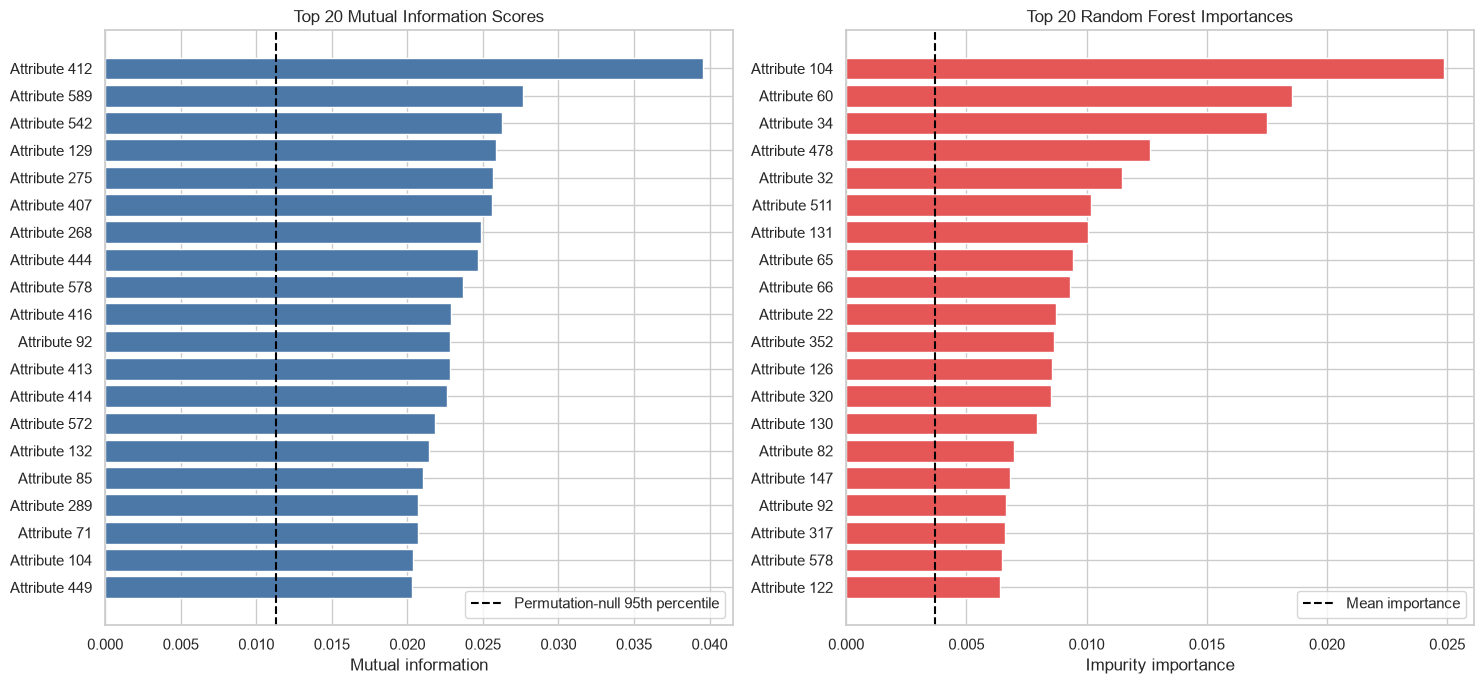

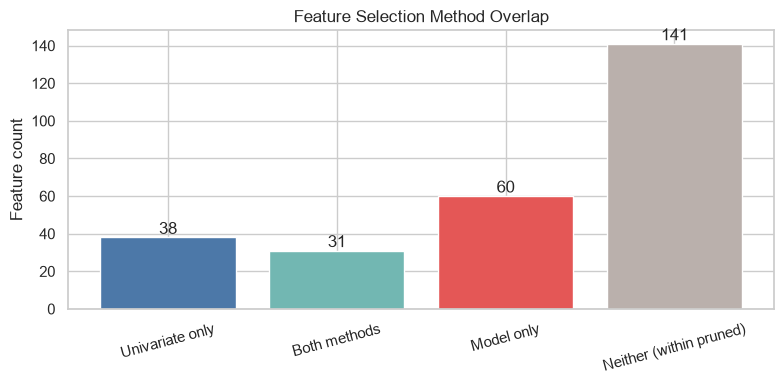

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
mi_plot = mi_scores_pruned.head(20).sort_values()
axes[0].barh(mi_plot.index, mi_plot.values, color='#4C78A8')
axes[0].axvline(mi_null_threshold, color='black', linestyle='--', label='Permutation-null 95th percentile')
axes[0].set(title='Top 20 Mutual Information Scores', xlabel='Mutual information')
axes[0].legend()
rf_plot = rf_importance.head(20).sort_values()
axes[1].barh(rf_plot.index, rf_plot.values, color='#E45756')
axes[1].axvline(rf_threshold, color='black', linestyle='--', label='Mean importance')
axes[1].set(title='Top 20 Random Forest Importances', xlabel='Impurity importance')
axes[1].legend()
fig.tight_layout()
importance_figure = FIGURES_DIR / 'feature_selection_top_importances.png'
fig.savefig(importance_figure, dpi=160, bbox_inches='tight')
plt.show()

set_c, set_d = set(univariate_features), set(model_features)
overlap_counts = pd.Series({
    'Univariate only': len(set_c - set_d),
    'Both methods': len(set_c & set_d),
    'Model only': len(set_d - set_c),
    'Neither (within pruned)': len(set(kept_features) - (set_c | set_d)),
})
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(overlap_counts.index, overlap_counts.values, color=['#4C78A8', '#72B7B2', '#E45756', '#BAB0AC'])
ax.set(title='Feature Selection Method Overlap', ylabel='Feature count')
ax.tick_params(axis='x', rotation=15)
for i, value in enumerate(overlap_counts.values):
    ax.text(i, value, str(value), ha='center', va='bottom')
fig.tight_layout()
overlap_figure = FIGURES_DIR / 'feature_selection_method_overlap.png'
fig.savefig(overlap_figure, dpi=160, bbox_inches='tight')
plt.show()

## 8. Save reproducible subsets and summary

In [9]:
subset_path = REPORTS_DIR / 'feature_subsets.json'
subset_path.write_text(json.dumps(subsets, indent=2, ensure_ascii=False), encoding='utf-8')
summary = {
    'scope': 'Feature selection only; no final model performance claims',
    'split': {
        'test_size': 0.2, 'random_state': RANDOM_STATE,
        'train_samples': len(X_train_raw), 'train_fail_count': int(y_train.sum()),
        'test_samples': len(X_test_raw), 'test_fail_count': int(y_test.sum()),
    },
    'preprocessing_fit_on': 'train only',
    'train_constant_removed': len(constant_features),
    'train_high_missing_removed': len(high_missing_features),
    'missing_threshold': MISSING_THRESHOLD,
    'preprocessed_feature_count': X_train.shape[1],
    'correlation_threshold': CORRELATION_THRESHOLD,
    'correlation_removed_count': len(pruning_records),
    'correlation_pruned_feature_count': len(kept_features),
    'mi_null_permutations': 20,
    'mi_null_95_threshold': mi_null_threshold,
    'univariate_selected_count': len(univariate_features),
    'rf_estimators': 500,
    'rf_class_weight': 'balanced_subsample',
    'rf_importance_threshold': rf_threshold,
    'model_selected_count': len(model_features),
    'subset_counts': {name: len(features) for name, features in subsets.items()},
    'univariate_model_overlap_count': len(common_selected),
    'univariate_model_overlap_features': common_selected,
    'eda_top10_comparison': eda_comparison.reset_index(names='feature').to_dict(orient='records'),
}
summary_path = REPORTS_DIR / 'feature_selection_summary.json'
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "scope": "Feature selection only; no final model performance claims",
  "split": {
    "test_size": 0.2,
    "random_state": 42,
    "train_samples": 1253,
    "train_fail_count": 83,
    "test_samples": 314,
    "test_fail_count": 21
  },
  "preprocessing_fit_on": "train only",
  "train_constant_removed": 116,
  "train_high_missing_removed": 32,
  "missing_threshold": 0.4,
  "preprocessed_feature_count": 442,
  "correlation_threshold": 0.95,
  "correlation_removed_count": 172,
  "correlation_pruned_feature_count": 270,
  "mi_null_permutations": 20,
  "mi_null_95_threshold": 0.011305524075440642,
  "univariate_selected_count": 69,
  "rf_estimators": 500,
  "rf_class_weight": "balanced_subsample",
  "rf_importance_threshold": 0.0037037037037037034,
  "model_selected_count": 91,
  "subset_counts": {
    "A_preprocessed_all": 442,
    "B_correlation_pruned": 270,
    "C_correlation_plus_univariate": 69,
    "D_correlation_plus_model_based": 91
  },
  "univariate_model_overlap_count": 

## Scope boundary

A~D subset은 다음 Modeling 단계에서 동일한 CV·평가지표 아래 비교할 후보일 뿐이다. 이 노트북에서는 test 기반 selection, 최종 ROC-AUC/PR-AUC 주장, SMOTE, PCA, SHAP 및 tuning을 수행하지 않았다.